# Retail Data Wrangling and Analytics

In [0]:
# Import modules 
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql.window import Window
import seaborn as sns

# Load Data from PSQL into DataFrame

**Setup Docker Containers**

![](https://i.imgur.com/VQrBVBk.jpg)

```
#make sure you have both Jupyter and PSQL docker container running
docker ps

#Attach a bridge network to both containers so they can communicate with each other
docker network create jarvis-net
#this command works on running containers
docker network connect jarvis-net jarvis-jupyter
docker network connect jarvis-net jarvis-psql

#verify both containers are attached to the jarvis-net
docker network inspect trading-net

#Note: instead of using `localhost`, you should use container names as hostnames.
```

**Data Preperation**

- Use [pandas.read_sql](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_sql.html) api to load the PSQL retail table into a Pandas DataFrame

![](https://i.imgur.com/AmkAP63.jpg)

- Get familair with the transaction date with `df.head()`, `df.sample(10)`, `df.info()`, `df.describe()`, etc..



In [0]:
#install psql "driver"
!pip3 install psycopg2-binary


[notice] A new release of pip available: 22.2.2 -> 25.2
[notice] To update, run: pip install --upgrade pip


# Load CSV into Dataframe
Alternatively, the LGS IT team also dumped the transactional data into a [CSV file](https://raw.githubusercontent.com/jarviscanada/jarvis_data_eng_demo/feature/data/python_data_wrangling/data/online_retail_II.csv). However, the CSV header (column names) doesn't follow the snakecase or camelcase naming convention (e.g. `Customer ID` instead of `customer_id` or `CustomerID`). As a result, you will need to use Pandas to clean up the data before doing any analytics. In addition, unlike the PSQL scheme, CSV files do not have data types associated. Therefore, you will need to cast/convert certain columns into correct data types (e.g. DateTime, numbers, etc..)

**Data Preperation**

- Read the `data/online_retail_II.csv` file into a DataFrame
- Rename all columns to upper camelcase or snakecase
- Convert/cast all columns to the appropriate data types (e.g. datetime)

In [0]:
%sql
CREATE SCHEMA IF NOT EXISTS jarvis_training.raw; 
CREATE VOLUME IF NOT EXISTS jarvis_training.raw.retail_files;

In [0]:
# Loading CSV file into a Spark Dataframe
file_path = "/Volumes/jarvis_training/raw/retail_files/online_retail_II.csv"
retail_df = spark.read.format("csv").option("header", "true").option("inferSchema", "true").load(file_path)

retail_df.show()


+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|Price|Customer ID|       Country|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
| 489434|    85048|15CM CHRISTMAS GL...|      12|2009-12-01 07:45:00| 6.95|    13085.0|United Kingdom|
| 489434|   79323P|  PINK CHERRY LIGHTS|      12|2009-12-01 07:45:00| 6.75|    13085.0|United Kingdom|
| 489434|   79323W| WHITE CHERRY LIGHTS|      12|2009-12-01 07:45:00| 6.75|    13085.0|United Kingdom|
| 489434|    22041|"RECORD FRAME 7""...|      48|2009-12-01 07:45:00|  2.1|    13085.0|United Kingdom|
| 489434|    21232|STRAWBERRY CERAMI...|      24|2009-12-01 07:45:00| 1.25|    13085.0|United Kingdom|
| 489434|    22064|PINK DOUGHNUT TRI...|      24|2009-12-01 07:45:00| 1.65|    13085.0|United Kingdom|
| 489434|    21871| SAVE THE PLANET MUG|      24|2009-12-01 07:45:00| 1.2

# Total Invoice Amount Distribution

In [0]:
'''
1. Calculate the invoice amount. Note: an invoice consists of one or more items where each item is a row in the df. (hint: you need to GROUP BY invoice)
2. Draw the distribution of invoice amount with min, max, median, mod, and mean. However, you will notice many outlier data (e.g. invoices with large amounts).
3. Draw the distribution for the first 85 quantiles of the invoice amount data with min, max, median, mod, and mean.
'''

# Step 1: Calculate invoice amounts into one column where invoice amount = quantity * price
invoice_amounts = retail_df.groupBy("Invoice").agg(sum(col("Quantity") * col("Price")).alias("Invoice_Amount")).filter(col("Invoice_Amount").isNotNull())

invoice_amounts.cache()

invoice_amounts.show()

+-------+-------------------+
|Invoice|     Invoice_Amount|
+-------+-------------------+
| 489677|              192.0|
|C491017|              -4.95|
| 491045|              303.2|
| 491658| 155.05999999999997|
|C491705|              -22.5|
|C492541|              -99.0|
|C493168|-177.60000000000002|
| 493542|             118.75|
| 493977|             275.95|
|C493984|             -10.43|
| 494244|             6711.0|
| 494277|            1335.92|
|C494502|              -9.95|
| 495185|            2507.06|
| 495329|                0.0|
| 495594|                0.0|
|C495697|-126.24999999999999|
| 495783|              48.96|
| 496171| 199.29999999999998|
| 496233| 188.82999999999998|
+-------+-------------------+
only showing top 20 rows



Mode: $0.00

Full Dataset Statistics:
Min: $-168469.60
Max: $168469.60
Mean: $359.65
Median: $196.27


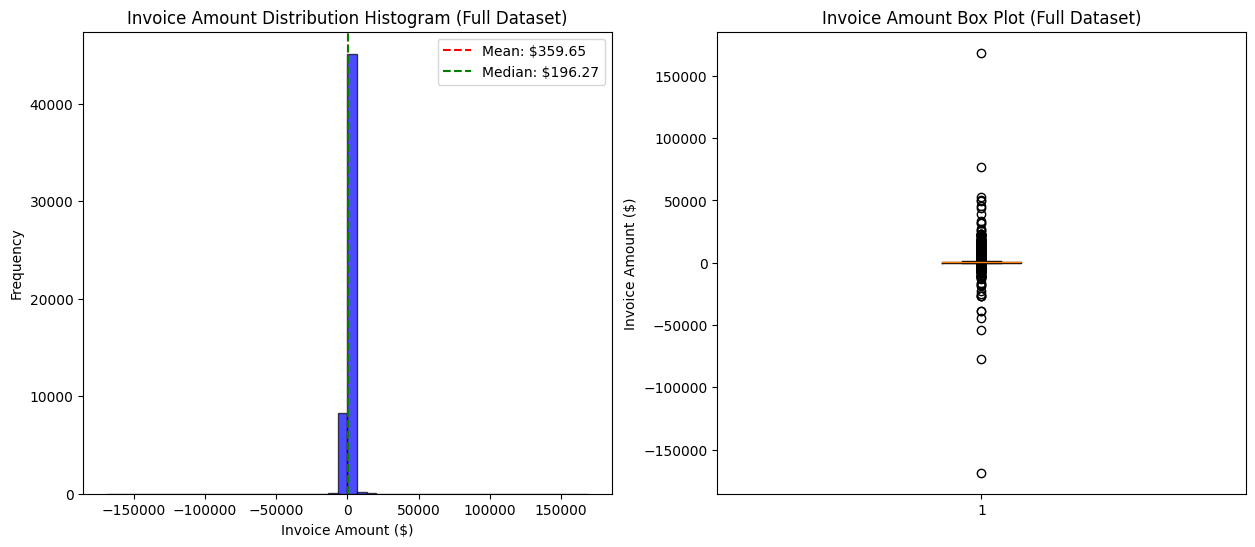

In [0]:
# Step 2: Calculate min, max, mean, median and mode for the whole dataset

# Getting the min, max, mean and median
all_stats = invoice_amounts.select(
    min("Invoice_Amount").alias("min"),
    max("Invoice_Amount").alias("max"),
    mean("Invoice_Amount").alias("mean"),
    expr("percentile_approx(Invoice_Amount, 0.5)").alias("median")
).collect()[0]

# Getting the mode
mode_result = invoice_amounts.groupBy("Invoice_Amount").count().orderBy(desc("count")).limit(1).collect()

if mode_result:
    mode_value = mode_result[0]["Invoice_Amount"]
    print(f"Mode: ${mode_value:.2f}")

# Showing collected stats
print("\nFull Dataset Statistics:")
print(f"Min: ${all_stats['min']:.2f}")
print(f"Max: ${all_stats['max']:.2f}")
print(f"Mean: ${all_stats['mean']:.2f}")
print(f"Median: ${all_stats['median']:.2f}")

# Plotting the graphs for full dataset
invoice_amounts_pd = invoice_amounts.toPandas()

# Histogram
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.hist(invoice_amounts_pd['Invoice_Amount'], bins=50, alpha=0.7, color='blue', edgecolor='black')
ax1.set_title('Invoice Amount Distribution Histogram (Full Dataset)')
ax1.set_xlabel('Invoice Amount ($)')
ax1.set_ylabel('Frequency')
ax1.axvline(all_stats['mean'], color='red', linestyle='--', label=f"Mean: ${all_stats['mean']:.2f}")
ax1.axvline(all_stats['median'], color='green', linestyle='--', label=f"Median: ${all_stats['median']:.2f}")
ax1.legend()

# Box Plot
ax2.boxplot(invoice_amounts_pd['Invoice_Amount'])
ax2.set_title('Invoice Amount Box Plot (Full Dataset)')
ax2.set_ylabel('Invoice Amount ($)')

plt.show()


85th Percentile: $594.00
Number of invoices in first 85 quantiles: 45583

Filtered Dataset Statistics (85 Quantiles): 
Min: $-168469.60
Max: $594.00
Mean: $136.98
Median: $141.85
Mode: $0.00


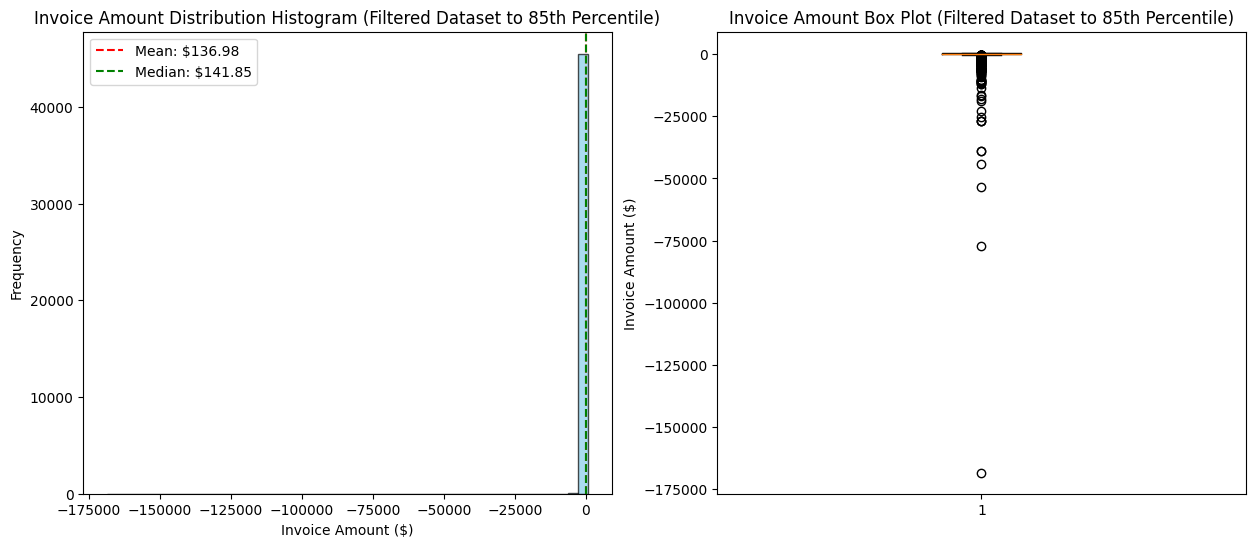

In [0]:
# Step 3: Distribution of Data to first 85 Quantiles (85th Percentile) along with new all_stats

percentile_85 = invoice_amounts.select(expr("percentile_approx(Invoice_Amount, 0.85)").alias("quantile_85")).collect()[0]["quantile_85"]

print(f"\n85th Percentile: ${percentile_85:.2f}")

filtered_invoice_amounts = invoice_amounts.filter(col("Invoice_Amount") <= percentile_85)
print(f"Number of invoices in first 85 quantiles: {filtered_invoice_amounts.count()}")

# Get statistics for filtered dataset (min, max, mean, median and mode)
all_stats_filtered = filtered_invoice_amounts.select(
    min("Invoice_Amount").alias("min_filtered"),
    max("Invoice_Amount").alias("max_filtered"),
    mean("Invoice_Amount").alias("mean_filtered"),
    expr("percentile_approx(Invoice_Amount, 0.5)").alias("median_filtered")
).collect()[0]

print("\nFiltered Dataset Statistics (85 Quantiles): ")
print(f"Min: ${all_stats_filtered['min_filtered']:.2f}")
print(f"Max: ${all_stats_filtered['max_filtered']:.2f}")
print(f"Mean: ${all_stats_filtered['mean_filtered']:.2f}")
print(f"Median: ${all_stats_filtered['median_filtered']:.2f}")

# Getting the mode
mode_filtered = filtered_invoice_amounts.groupBy("Invoice_Amount").count().orderBy(desc("count")).limit(1).collect()

if mode_filtered:
    mode_value_filtered = mode_filtered[0]["Invoice_Amount"]
    print(f"Mode: ${mode_value_filtered:.2f}")

# Plotting the graphs for the filtered dataset
filtered_invoice_amounts_pd = filtered_invoice_amounts.toPandas()

# Histogram
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.hist(filtered_invoice_amounts_pd['Invoice_Amount'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
ax1.set_title('Invoice Amount Distribution Histogram (Filtered Dataset to 85th Percentile)')
ax1.set_xlabel('Invoice Amount ($)')
ax1.set_ylabel('Frequency')
ax1.axvline(all_stats_filtered['mean_filtered'], color='red', linestyle='--', label=f"Mean: ${all_stats_filtered['mean_filtered']:.2f}")
ax1.axvline(all_stats_filtered['median_filtered'], color='green', linestyle='--', label=f"Median: ${all_stats_filtered['median_filtered']:.2f}")
ax1.legend()

# Box Plot
ax2.boxplot(filtered_invoice_amounts_pd['Invoice_Amount'])
ax2.set_title('Invoice Amount Box Plot (Filtered Dataset to 85th Percentile)')
ax2.set_ylabel('Invoice Amount ($)')

plt.show()

# Monthly Placed and Canceled Orders

In [0]:
'''
- The attribute information (see the project kick-off section) contains useful information that helps you to identify canceled orders
- To simplify the problem, you can assume that there are two invoice numbers for each canceled order (one for the original invoice and one for the canceled invoice). Therefore, # of placed orders = total # of orders - 2 * canceled order. Furthermore, you can also assume the original invoice and canceled invoice are on always on the same day (this eliminate the case where the original invoice and canceled invoices are on different months)
- hints: you might want to create a new integer column with YYYYMM format. e.g. 2009-12-01 07:45:00 -> 200912 which allows easy GROUP BY.
'''


# Create yyyyMM column from invoice date in dataset
df_month = retail_df.withColumn("YearMonth", date_format(col("InvoiceDate"), "yyyyMM").cast("Integer"))

# Identify cancelled orders
# Cancelled orders usually have a 'C' written next to their StockCode or are negative quantities
print("Exploring potential cancellation patterns:")
print("\n Sample of negative quantities: ")
df_month.filter(col("Quantity") < 0).select("Invoice", "StockCode", "Quantity", "Description").show(5)

print("\n Sample of StockCode with 'C': ")
df_month.filter(col("StockCode").startswith("C")).select("Invoice", "StockCode", "Quantity", "Description").show(5)

# Flagging cancelled orders (We use negative quantities as they are more accurate and consistent)
flagged_orders_df = df_month.withColumn("IsCancelled", when(col("Quantity") < 0, True).otherwise(False))

# Get unique invoices per month while displaying cancellation status
monthly_invoices = flagged_orders_df.groupBy("YearMonth", "Invoice").agg(max("IsCancelled").alias("HasCancellation"), sum("Quantity").alias("TotalQuantity"))

# Counting orders by month
summary_monthly = monthly_invoices.groupBy("YearMonth").agg(count('*').alias("TotalInvoices"), sum(when(col("HasCancellation") == True, 1).otherwise(0)).alias("CancelledInvoices")).withColumn("PlacedOrders", col("TotalInvoices") - 2 * col("CancelledInvoices")).orderBy("YearMonth")
summary_monthly.display()

Exploring potential cancellation patterns:

 Sample of negative quantities: 
+-------+---------+--------+--------------------+
|Invoice|StockCode|Quantity|         Description|
+-------+---------+--------+--------------------+
|C489449|    22087|     -12|PAPER BUNTING WHI...|
|C489449|   85206A|      -6|CREAM FELT EASTER...|
|C489449|    21895|      -4|POTTING SHED SOW ...|
|C489449|    21896|      -6|  POTTING SHED TWINE|
|C489449|    22083|     -12|PAPER CHAIN KIT R...|
+-------+---------+--------+--------------------+
only showing top 5 rows


 Sample of StockCode with 'C': 
+-------+---------+--------+-----------+
|Invoice|StockCode|Quantity|Description|
+-------+---------+--------+-----------+
| 490127|       C2|       1|   CARRIAGE|
| 490541|       C2|       1|   CARRIAGE|
| 490542|       C2|       1|   CARRIAGE|
| 490998|       C2|       1|   CARRIAGE|
| 491160|       C2|       1|   CARRIAGE|
+-------+---------+--------+-----------+
only showing top 5 rows



YearMonth,TotalInvoices,CancelledInvoices,PlacedOrders
200912,2330,491,1348
201001,1633,428,777
201002,1969,687,595
201003,2367,597,1173
201004,1892,379,1134
201005,2418,776,866
201006,2216,497,1222
201007,2017,432,1153
201008,1877,366,1145
201009,2375,464,1447


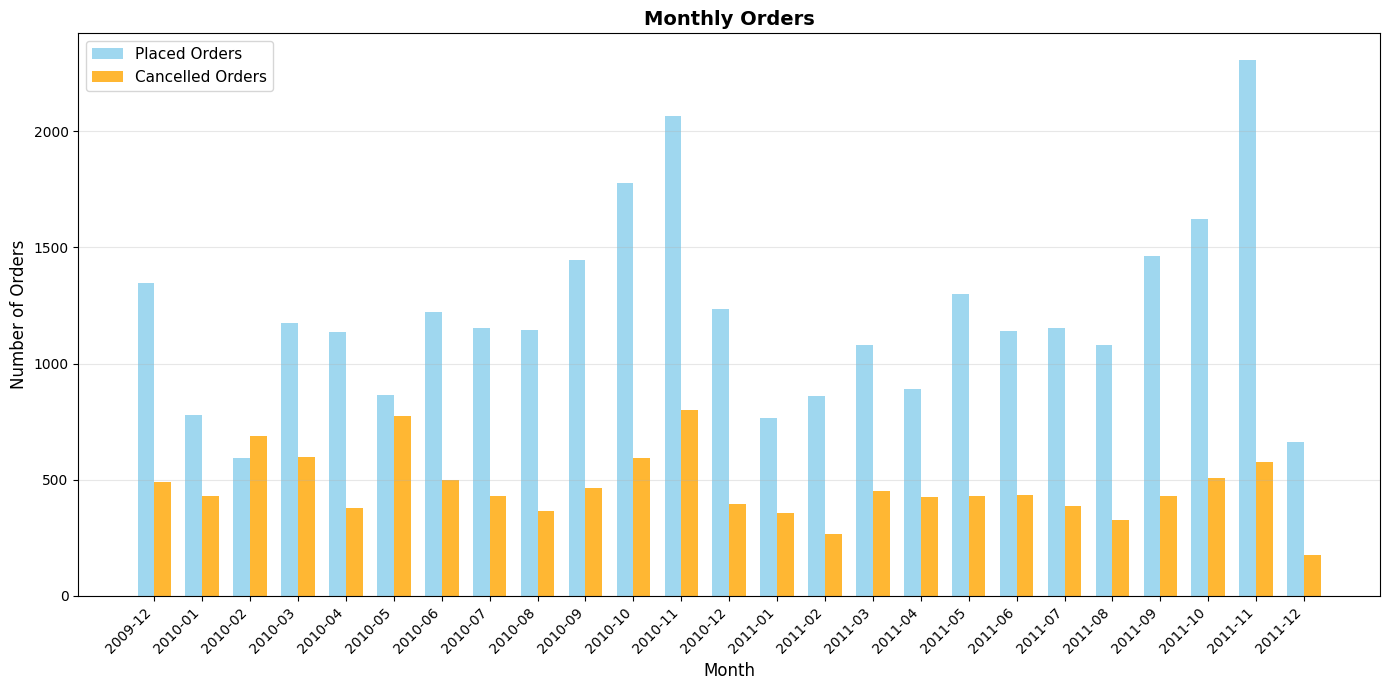

In [0]:
# Plotting the graphs for the placed and cancelled orders per month
summary_monthly_pd = summary_monthly.toPandas()

# Changing yyyyMM to datetime format for better visual appeal
summary_monthly_pd['Date'] = pd.to_datetime(summary_monthly_pd['YearMonth'].astype(str), format='%Y%m')
summary_monthly_pd['MonthYear'] = summary_monthly_pd['Date'].dt.strftime('%Y-%m')

# Plotting graphs
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(summary_monthly_pd))
width = 0.35

# 'PlacedOrders' and 'CancelledOrders' will be next to each other
bars1 = ax.bar(x - width/2, summary_monthly_pd['PlacedOrders'], width=width, label='Placed Orders', color='skyblue', alpha=0.8)

bars2 = ax.bar(x + width/2, summary_monthly_pd['CancelledInvoices'], width=width, label= 'Cancelled Orders', color='orange', alpha=0.8)

# Set x-axis to show each month-year (yyyyMM)
ax.set_xticks(x)
ax.set_xticklabels(summary_monthly_pd['MonthYear'], rotation=45, ha='right')

ax.set_title('Monthly Orders', fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Orders', fontsize=12)
ax.legend(fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Monthly Sales

In [0]:
'''
- Calculate the monthly sales data
- Plot a chart to show monthly sales (e.g. x-asix=year_month, y-axis=sales_amount)
'''


# Calculation of monthly sales

# Create yyyyMM column from invoice date in dataset
month_df = retail_df.withColumn("YearMonth", date_format(col("InvoiceDate"), "yyyyMM").cast("Integer"))

# Getting the monthly sales
# Sum of Quantity * Price per Month
monthly_sales = month_df.groupBy("YearMonth") \
    .agg(
        sum(col("Quantity") * col("Price")).alias("TotalSales"), 
        count("*").alias("Total Transactions"), 
        countDistinct("Invoice").alias("UniqueInvoices"), 
        countDistinct("Customer ID").alias("UniqueCustomers")) \
        .orderBy("YearMonth")

print("Monthly Sales Summary: ")
display(monthly_sales)

# Monthly Sales Statistics
sales_stats = monthly_sales.select(
    min("TotalSales").alias("min_sales"),
    max("TotalSales").alias("max_sales"),
    mean("TotalSales").alias("mean_sales"),
    sum("TotalSales").alias("sum_sales")
).collect()[0]

print("=================================")
print("TOTAL SALES STATISTICS")
print("=================================")
print(f"Total Sales (All Time): ${sales_stats['sum_sales']:,.2f}")
print(f"Average Monthly Sales: ${sales_stats['mean_sales']:,.2f}")
print(f"Minimum Monthly Sales: ${sales_stats['min_sales']:,.2f}")
print(f"Maximum Monthly Sales: ${sales_stats['max_sales']:,.2f}")

Monthly Sales Summary: 


YearMonth,TotalSales,Total Transactions,UniqueInvoices,UniqueCustomers
200912,799847.1100000143,45228,2330,1045
201001,624032.8919999956,31555,1633,786
201002,533091.4260000042,29388,1969,807
201003,765848.7609999765,41511,2367,1111
201004,590580.4319999823,34057,1892,998
201005,615322.8300000005,35323,2418,1062
201006,679786.6099999842,39983,2216,1095
201007,575236.360000009,33383,2017,988
201008,656776.3399999854,33306,1877,964
201009,853650.4309999745,42091,2375,1202


TOTAL SALES STATISTICS
Total Sales (All Time): $19,287,250.57
Average Monthly Sales: $771,490.02
Minimum Monthly Sales: $433,686.01
Maximum Monthly Sales: $1,461,756.25


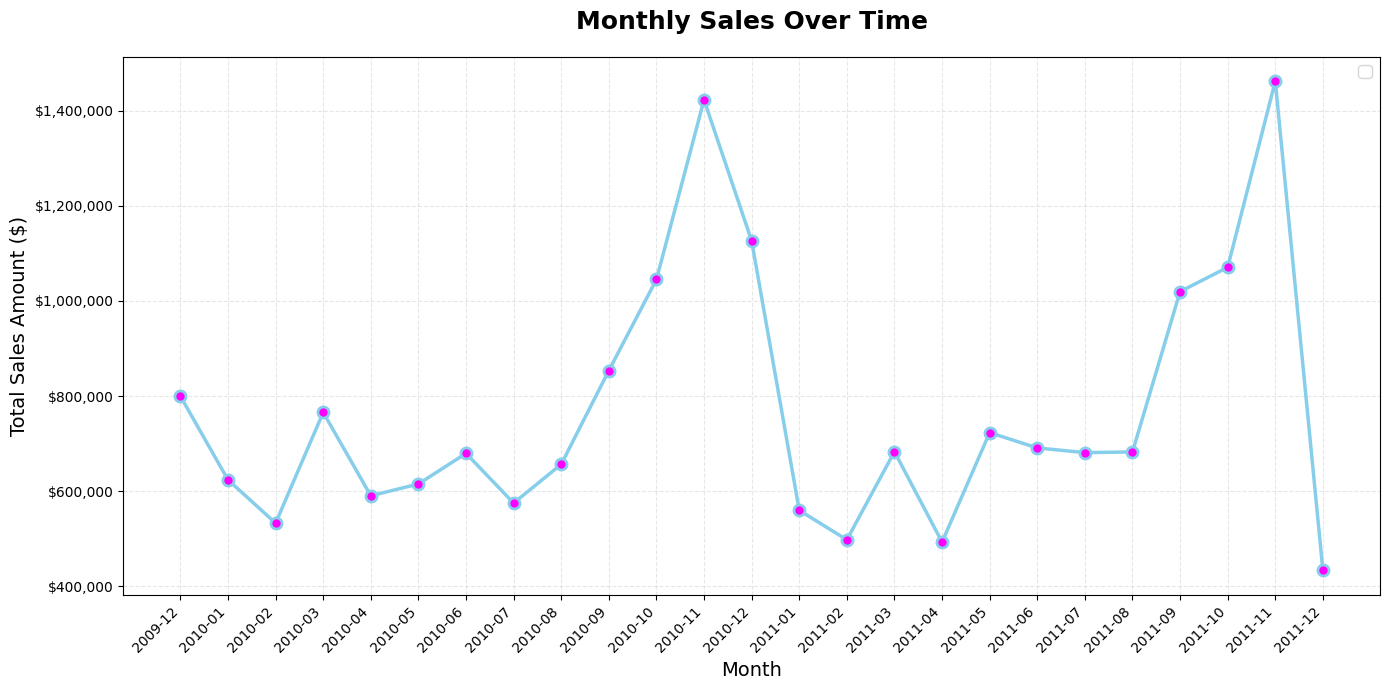

In [0]:
# Plotting Graph of Monthly Sales
monthly_sales_pd = monthly_sales.toPandas()

# Changing 'YearMonth' to datetime for better visual appeal
monthly_sales_pd['Date'] = pd.to_datetime(monthly_sales_pd['YearMonth'].astype(str), format='%Y%m')
monthly_sales_pd['MonthYear'] = monthly_sales_pd['Date'].dt.strftime('%Y-%m')

# Creating Plot
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(monthly_sales_pd))

ax.plot(x, monthly_sales_pd['TotalSales'], marker='o', linewidth=2.5, markersize=8, color='skyblue', markerfacecolor='magenta', markeredgewidth=2, markeredgecolor='skyblue')

ax.set_xticks(x)
ax.set_xticklabels(monthly_sales_pd['MonthYear'], rotation=45, ha='right')

ax.set_title('Monthly Sales Over Time', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=14)
ax.set_ylabel('Total Sales Amount ($)', fontsize=14)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=12)

# Formatting y-axis to show sales amount in millions ($)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Monthly Sales Growth


In [0]:
'''
- Calculate monthly sales percentage growth data
- Plot a chart to show the growth percentage
'''

# Calculation of Monthly Sales Growth

# Create yyyyMM column from invoice date in dataset
month_df_growth = retail_df.withColumn("YearMonth", date_format(col("InvoiceDate"), "yyyyMM").cast("Integer"))

sales_monthly = month_df_growth.groupBy("YearMonth") \
    .agg(sum(col("Quantity") * col("Price")).alias("TotalSales")) \
        .orderBy("YearMonth")

window_spec = Window.orderBy("YearMonth")

sales_monthly_growth = sales_monthly.withColumn(
    "PreviousMonthSales",
    lag("TotalSales", 1).over(window_spec)
).withColumn(
    "GrowthPercentage",
    ((col("TotalSales") - col("PreviousMonthSales")) / col("PreviousMonthSales") * 100)
).withColumn(
    "GrowthAmount",
    col("TotalSales") - col("PreviousMonthSales")
)

print("Monthly Sales with Growth Percentage")
display(sales_monthly_growth)

# Monthly Sales Growth Statistics
growth_stats = sales_monthly_growth.select(
    min("GrowthPercentage").alias("min_growth"),
    max("GrowthPercentage").alias("max_growth"),
    mean("GrowthPercentage").alias("mean_growth"),
    count(when(col("GrowthPercentage") > 0, 1)).alias("positive_growth_months"),
    count(when(col("GrowthPercentage") < 0, 1)).alias("negative_growth_months")
).collect()[0]

print("=================================")
print("MONTHLY SALES GROWTH STATISTICS")
print("=================================")
print(f"Positive Growth Months: {growth_stats['positive_growth_months']}")
print(f"Negative Growth Months: {growth_stats['negative_growth_months']}")
print(f"Average Growth Rate: {growth_stats['mean_growth']:.2f}%")
print(f"Minimum Growth Months: {growth_stats['min_growth']:.2f}%")
print(f"Maximum Growth Months: {growth_stats['max_growth']:.2f}%")

Monthly Sales with Growth Percentage


YearMonth,TotalSales,PreviousMonthSales,GrowthPercentage,GrowthAmount
200912,799847.1100000143,null,null,null
201001,624032.8919999956,799847.1100000143,-21.980978089677112,-175814.21800001874
201002,533091.4260000042,624032.8919999956,-14.573184709627782,-90941.4659999914
201003,765848.7609999765,533091.4260000042,43.661804269943474,232757.33499997237
201004,590580.4319999823,765848.7609999765,-22.885501410375667,-175268.3289999942
201005,615322.8300000005,590580.4319999823,4.18950521544184,24742.398000018205
201006,679786.6099999842,615322.8300000005,10.476416095268814,64463.77999998361
201007,575236.360000009,679786.6099999842,-15.379863101448505,-104550.2499999752
201008,656776.3399999854,575236.360000009,14.175039282978426,81539.97999997647
201009,853650.4309999745,656776.3399999854,29.975819622246664,196874.09099998907


MONTHLY SALES GROWTH STATISTICS
Positive Growth Months: 13
Negative Growth Months: 11
Average Growth Rate: 3.12%
Minimum Growth Months: -70.33%
Maximum Growth Months: 49.37%


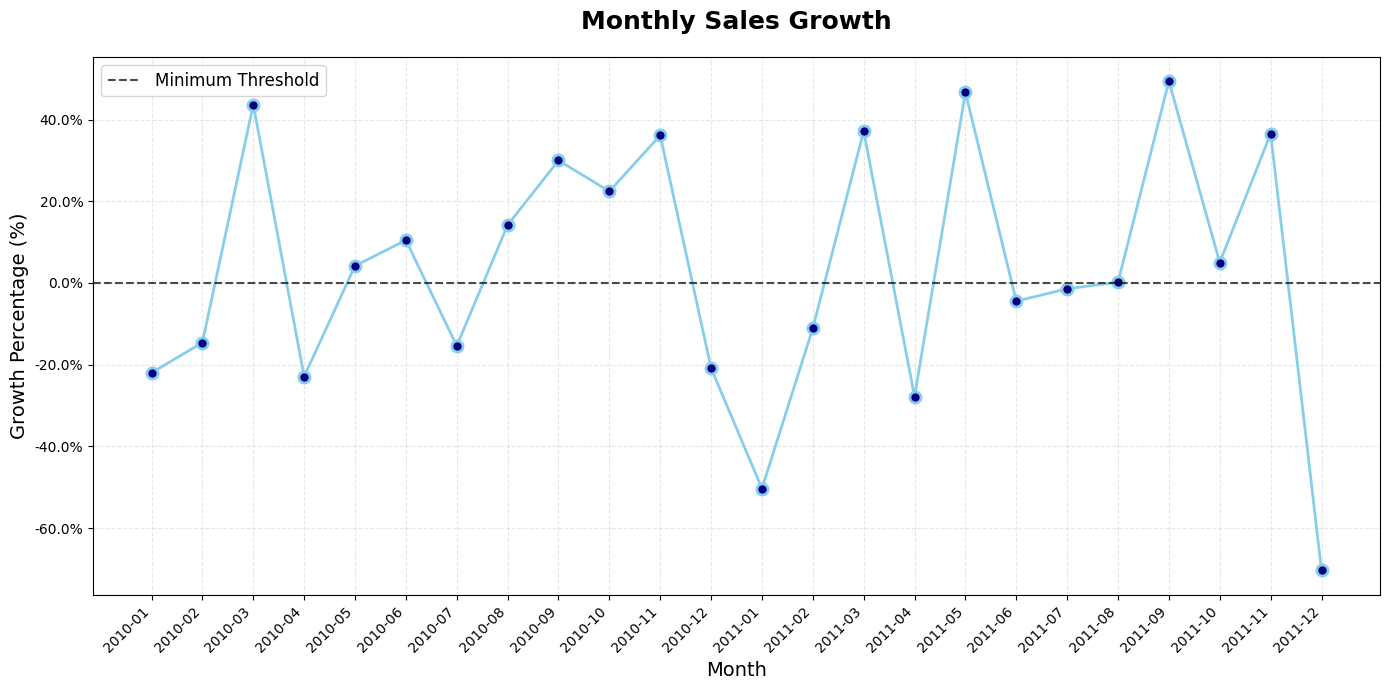

In [0]:
# Graph of Monthly Growth Sales

# Converts Spark DataFrame into Pandas DataFrame
sales_monthly_growth_pd = sales_monthly_growth.toPandas()

sales_monthly_growth_pd['Date'] = pd.to_datetime(sales_monthly_growth_pd['YearMonth'].astype(str), format='%Y%m')
sales_monthly_growth_pd['MonthYear'] = sales_monthly_growth_pd['Date'].dt.strftime('%Y-%m')

# Creating Plot
fig, ax = plt.subplots(figsize=(14, 7))

growth_data = sales_monthly_growth_pd[sales_monthly_growth_pd['GrowthPercentage'].notna()].copy()

x = np.arange(len(growth_data))

# Plotting the graph
ax.plot(x, growth_data['GrowthPercentage'], marker='o', linewidth=2, markersize=8, color='skyblue', markerfacecolor='navy', markeredgewidth=2, markeredgecolor='skyblue')

# Adding a horizontal zero line
ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Minimum Threshold')

ax.set_xticks(x)
ax.set_xticklabels(growth_data['MonthYear'], rotation=45, ha='right')

ax.set_title('Monthly Sales Growth', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=14)
ax.set_ylabel('Growth Percentage (%)', fontsize=14)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=12)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.1f}%'))

plt.tight_layout()
plt.show()


# Monthly Active Users

In [0]:
'''
- Compute # of active users (e.g. unique CusotomerID) for each month
- Plot a bar chart
'''

# Compute the active number of users

# Create yyyyMM column from invoice date in dataset
each_month_df = retail_df.withColumn("YearMonth", date_format(col("InvoiceDate"), "yyyyMM").cast("Integer"))

# Get monthly active users
monthly_active_users = each_month_df.groupBy("YearMonth") \
    .agg(
        countDistinct("Customer ID").alias("ActiveUsers"),
        count("*").alias("TotalTransactions"),
        countDistinct("Invoice").alias("UniqueInvoices")
    ) \
        .orderBy("YearMonth")

display(monthly_active_users)

# Monthly User Statistics
user_stats = monthly_active_users.select(
    min("ActiveUsers").alias("min_users"),
    max("ActiveUsers").alias("max_users"),
    mean("ActiveUsers").alias("mean_users"),
    sum("ActiveUsers").alias("sum_users")
).collect()[0]

print("=================================")
print("MONTHLY ACTIVE USERS STATISTICS")
print("=================================")
print(f"Average Monthly Active Users: {user_stats['mean_users']:.0f}")
print(f"Minimum Monthly Active Users: {user_stats['min_users']}")
print(f"Maximum Monthly Active Users: {user_stats['max_users']}")
print(f"Total Monthly Active Users: {user_stats['sum_users']}")



YearMonth,ActiveUsers,TotalTransactions,UniqueInvoices
200912,1045,45228,2330
201001,786,31555,1633
201002,807,29388,1969
201003,1111,41511,2367
201004,998,34057,1892
201005,1062,35323,2418
201006,1095,39983,2216
201007,988,33383,2017
201008,964,33306,1877
201009,1202,42091,2375


MONTHLY ACTIVE USERS STATISTICS
Average Monthly Active Users: 1080
Minimum Monthly Active Users: 686
Maximum Monthly Active Users: 1711
Total Monthly Active Users: 26993


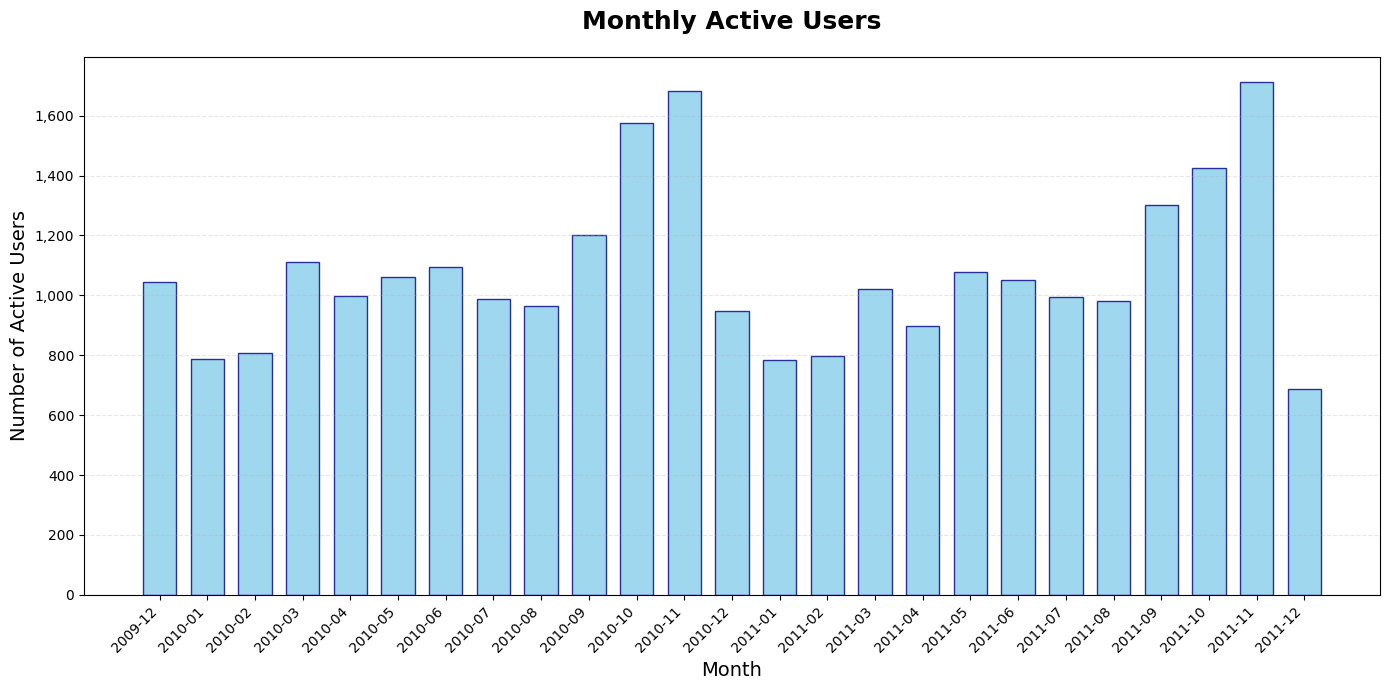

In [0]:
# Plotting Graph of Monthly Active Users

# Convert Spark DataFrame into Pandas DataFrame
monthly_users_pd = monthly_active_users.toPandas()

# Converting 'YearMonth' to a readable format 
monthly_users_pd['Date'] = pd.to_datetime(monthly_users_pd['YearMonth'].astype(str), format='%Y%m')
monthly_users_pd['MonthYear'] = monthly_users_pd['Date'].dt.strftime('%Y-%m')

# Creating the bar graph
fig, ax = plt.subplots(figsize=(14, 7))

# Setting the x-axis
x = np.arange(len(monthly_users_pd))

# Setting the bar graph chart
bars = ax.bar(x, monthly_users_pd['ActiveUsers'], color='skyblue', alpha=0.8, edgecolor='navy', width=0.7)

# Setting the x-axis to show each month
ax.set_xticks(x)
ax.set_xticklabels(monthly_users_pd['MonthYear'], rotation=45, ha='right')

# Setting titles
ax.set_title('Monthly Active Users', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=14)
ax.set_ylabel('Number of Active Users', fontsize=14)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.show()

# New and Existing Users



In [0]:
'''
- Plot a diagram to show new and exiting user for each month.
- A user is identified as a new user when he/she makes the first purchase
- A user is identified as an existing user when he/she made purchases in the past
- hints:
    - find out the first purchase year-month for each user and then join this data with the transactional data to help you identified new/exiting users
'''

# Get number of New and Existing Users

# Create yyyyMM column from invoice date in dataset
df_with_month = retail_df.withColumn("YearMonth", date_format(col("InvoiceDate"), "yyyyMM").cast("Integer"))

# Getting first time users
first_purchase = df_with_month.groupBy("Customer ID") \
    .agg(min("YearMonth").alias("FirstPurchaseMonth")) \
        .filter(col("Customer ID").isNotNull())

# Left join of df_with_month with first purchase to get first time users
df_first_purchase = df_with_month.join(first_purchase, on="Customer ID", how="left")

# Differentiates between first time users and regular users
df_classified = df_first_purchase.withColumn("UserType", when(col("YearMonth") == col("FirstPurchaseMonth"), "New").otherwise("Existing"))

# Counting new and existing users per month
user_types_monthly = df_classified.groupBy("YearMonth", "UserType") \
    .agg(countDistinct("Customer ID").alias("UserCount")) \
        .orderBy("YearMonth", "UserType")

# Modify DataFrame to have a 'New' and 'Existing' column next to 'YearMonth' (That's why I called it 'pivot')
pivot_users_monthly = user_types_monthly.groupBy("YearMonth") \
    .pivot("UserType") \
        .agg(first("UserCount")) \
            .na.fill(0) \
                .orderBy("YearMonth")

# Add columns 'New' and 'Existing' if they don't exist and to show first time users and regular users
if "New" not in pivot_users_monthly.columns:
    pivot_users_monthly = pivot_users_monthly.withColumn("New", lit(0))

if "Existing" not in pivot_users_monthly.columns:
    pivot_users_monthly = pivot_users_monthly.withColumn("Existing", lit(0))

pivot_users_monthly = pivot_users_monthly.select("YearMonth", "New", "Existing")

display(pivot_users_monthly)

# New and Existing Users Statistics
sum_new_users = pivot_users_monthly.agg(sum("New")).collect()[0][0]
sum_existing_users = pivot_users_monthly.agg(sum("Existing")).collect()[0][0]

print("=================================")
print("NEW AND EXISTING USERS STATISTICS")
print("=================================")
print(f"Total New Users: {sum_new_users:,}")
print(f"Total Existing Users: {sum_existing_users:,}")
print(f"Total Users: {sum_new_users + sum_existing_users:,}")

YearMonth,New,Existing
200912,1045,0
201001,394,392
201002,363,444
201003,436,675
201004,291,707
201005,254,808
201006,269,826
201007,183,805
201008,158,806
201009,242,960


NEW AND EXISTING USERS STATISTICS
Total New Users: 5,942
Total Existing Users: 21,051
Total Users: 26,993


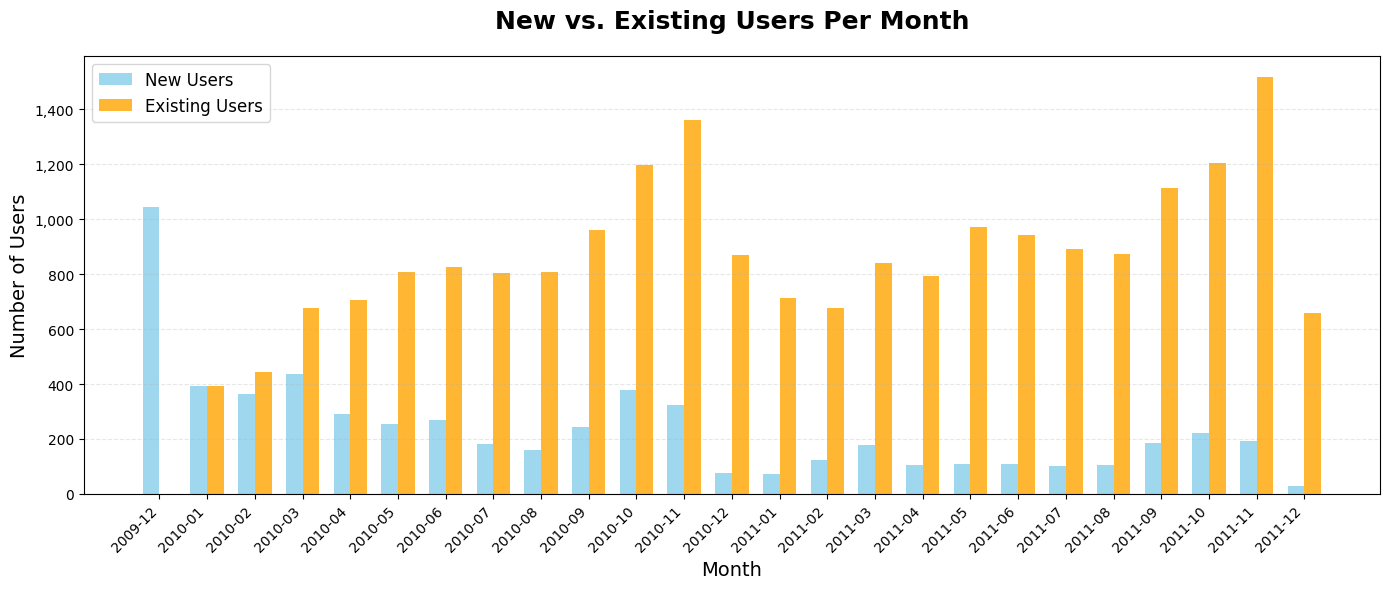

In [0]:
# Plotting New and Existing Users in a Bar Graph

# Changing Spark Dataframe into Pandas DataFrame
pivot_users_monthly_pd = pivot_users_monthly.toPandas()

pivot_users_monthly_pd['Date'] = pd.to_datetime(pivot_users_monthly_pd['YearMonth'].astype(str), format='%Y%m')
pivot_users_monthly_pd['MonthYear'] = pivot_users_monthly_pd['Date'].dt.strftime('%Y-%m')

# Creating PLot
fig, ax = plt.subplots(figsize=(14, 6))

# Setting the x-axis to show each month
x = np.arange(len(pivot_users_monthly_pd))
width = 0.35

# Plotting data into bar graph
bars1 = ax.bar(x - width/2, pivot_users_monthly_pd['New'], width=width, label='New Users', color='skyblue', alpha=0.8)

bars2 = ax.bar(x + width/2, pivot_users_monthly_pd['Existing'], width=width, label='Existing Users', color='orange', alpha=0.8)

# Shows each month on x-axis
ax.set_xticks(x)
ax.set_xticklabels(pivot_users_monthly_pd['MonthYear'], rotation=45, ha='right')

# Setting titles and labels
ax.set_title('New vs. Existing Users Per Month', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=14)
ax.set_ylabel('Number of Users', fontsize=14)
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3, linestyle='--', axis='y')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.show()

## Finding RFM

RFM is a method used for analyzing customer value. It is commonly used in database marketing and direct marketing and has received particular attention in the retail and professional services industries. ([wikipedia](https://en.wikipedia.org/wiki/RFM_(market_research)))

Optional Reading: [Making Your Database Pay Off Using Recency Frequency and Monetary Analysis](http://www.dbmarketing.com/2010/03/making-your-database-pay-off-using-recency-frequency-and-monetary-analysis/)


RFM stands for three dimensions:

- Recency – How recently did the customer purchase?

- Frequency – How often do they purchase?

- Monetary Value – How much do they spend?

Note: To simplify the problem, let's keep all placed and canceled orders.


**Sample RFM table**

![](https://i.imgur.com/sXFIg6u.jpg)

# RFM Segmentation

In [0]:
# RFM Segmentation
from pyspark.sql.functions import (
    col, max as spark_max, min as spark_min, countDistinct, sum as spark_sum, datediff, lit, when, concat_ws, row_number, ntile
)
from pyspark.sql.window import Window

 # Filter out rows with null Customer ID and get TotalPrice
rfm_df = retail_df.filter(col("Customer ID").isNotNull()).withColumn("TotalPrice", col("Quantity") * col("Price"))

# Get the latest InvoiceDate in the dataset
latest_date = rfm_df.agg(spark_max("InvoiceDate")).collect()[0][0]

# Calculate RFM stats
rfm_stats = rfm_df.groupBy("Customer ID").agg(
    datediff(lit(latest_date), spark_max("InvoiceDate")).alias("Recency"),
    countDistinct("Invoice").alias("Frequency"),
    spark_sum("TotalPrice").alias("Monetary")
)

# Score each stat using quintiles (1=lowest, 5=highest)
for stat in ["Recency", "Frequency", "Monetary"]:
    order = "asc" if stat == "Recency" else "desc"
    w = Window.orderBy(col(stat).asc() if order == "asc" else col(stat).desc())
    rfm_stats = rfm_stats.withColumn(
        f"{stat}Score",
        ntile(5).over(w)
    )

# Combine RFM scores
rfm_stats = rfm_stats.withColumn(
    "RFMScore",
    concat_ws("", col("RecencyScore"), col("FrequencyScore"), col("MonetaryScore"))
)

# Segmentation of RFM Table and Stats
# Add new column called 'Segment' for RFM Segmentation of Customers
segmentation_legend = rfm_stats.withColumn(
    "Segment",
    when((col("RecencyScore") >= 4) & (col("FrequencyScore") >= 4) & (col("MonetaryScore") >= 4), "Champions")
    .when((col("RecencyScore") >= 3) & (col("FrequencyScore") >= 3) & (col("MonetaryScore") >= 3), "Loyal Customers")
    .when((col("RecencyScore") >= 4) & (col("FrequencyScore") <= 2) & (col("MonetaryScore") >= 2), "Potential Loyalists")
    .when((col("RecencyScore") >= 3) & (col("FrequencyScore") <= 3) & (col("MonetaryScore") <= 3), "Promising")
    .when((col("RecencyScore") >=4) & (col("FrequencyScore") <= 1) & (col("MonetaryScore") <= 1), "New Customers")
    .when((col("RecencyScore") <= 2) & (col("FrequencyScore") >= 3) & (col("MonetaryScore") >= 3), "At Risk")
    .when((col("RecencyScore") <= 2) & (col("FrequencyScore") >= 4) & (col("MonetaryScore") >= 4), "Can't Lose Them")
    .when((col("RecencyScore") <= 2) & (col("FrequencyScore") <= 2) & (col("MonetaryScore") <= 2), "Hibernating")
    .when((col("RecencyScore") <= 1) & (col("FrequencyScore") <= 2) & (col("MonetaryScore") <= 2), "Lost")
    .when((col("RecencyScore") >= 3) & (col("FrequencyScore") == 1) & (col("MonetaryScore") == 1), "About to Sleep")
    .otherwise("Need Attention")
)

rfm_stats.show()

print("Sample Segmented Customers: ")
segmentation_legend.select("Customer ID", "RFMScore", "Segment", "Recency", "Frequency", "Monetary").show()

+-----------+-------+---------+------------------+------------+--------------+-------------+--------+
|Customer ID|Recency|Frequency|          Monetary|RecencyScore|FrequencyScore|MonetaryScore|RFMScore|
+-----------+-------+---------+------------------+------------+--------------+-------------+--------+
|    18102.0|      0|      153| 598215.2199999997|           1|             1|            1|     111|
|    14646.0|      1|      164| 523342.0699999999|           1|             1|            1|     111|
|    14156.0|      9|      202| 296564.6899999999|           1|             1|            1|     111|
|    14911.0|      1|      510|270248.52999999997|           1|             1|            1|     111|
|    17450.0|      8|       61|233579.38999999996|           1|             1|            1|     111|
|    13694.0|      3|      164|190825.52000000008|           1|             1|            1|     111|
|    17511.0|      2|       85|171885.97999999995|           1|             1|    